# ==============================================================================
# 🫁 THORACIC ONCOLOGY MORTALITY SURVIVAL: ENTERPRISE SURVIVAL ANALYSIS
# Subtitle: NCCTG Lung Cancer Patient Clinical Performance to Survival Duration
# Paradigm: Cox Proportional Hazards Model (Semi-Parametric Time-to-Event Analysis)
# Standard: Enterprise 13-Step Production-Grade Architecture
# ==============================================================================

## Theoretical Framework: Survival Analysis & Right-Censoring
In standard supervised learning, observations without an observed event by study termination are either discarded or treated as negative, inducing severe survivorship bias.

**Survival Analysis** directly models the time $T$ until an event of interest occurs under **right-censoring** (where $T > c_i$ for censored subjects).
The fundamental survival quantity is the survival function $S(t) = P(T > t)$ and hazard rate:
$$h(t) = \lim_{\Delta t \to 0} \frac{P(t \le T < t + \Delta t \mid T \ge t)}{\Delta t}$$

The **Cox Proportional Hazards Model (Cox, 1972)** models the hazard multiplicatively without assuming an explicit parametric baseline hazard distribution:
$$h(t \mid \mathbf{x}) = h_0(t) \exp(\mathbf{x}^T \boldsymbol{\beta})$$

The partial likelihood over distinct event times $t_1 < t_2 < \dots < t_E$ is given by:
$$L(\boldsymbol{\beta}) = \prod_{i=1}^E \frac{\exp(\mathbf{x}_i^T \boldsymbol{\beta})}{\sum_{j \in \mathcal{R}(t_i)} \exp(\mathbf{x}_j^T \boldsymbol{\beta})}$$
where $\mathcal{R}(t_i)$ is the risk set of individuals alive and uncensored immediately prior to $t_i$.
Model discrimination is evaluated via **Harrell's Concordance Index (C-index)**:
$$C = \frac{\sum_{i, j} \mathbb{I}(T_i < T_j) \cdot \mathbb{I}(\hat{h}_i > \hat{h}_j) \cdot E_i}{\sum_{i, j} \mathbb{I}(T_i < T_j) \cdot E_i}$$


In [1]:
# STEP 1: ENVIRONMENT & REPRODUCIBILITY
import os
import sys
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import concordance_index
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import KFold

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("✅ STEP 1: Environment initialized.")


✅ STEP 1: Environment initialized.


In [2]:
# STEP 2: DATA INGESTION & CENSORED EVENT SETUP

from lifelines.datasets import load_lung
df = load_lung().dropna().reset_index(drop=True)
if 'inst' in df.columns: df = df.drop(columns=['inst'])
df = pd.get_dummies(df, drop_first=True, dtype=float)
duration_col = 'time'
event_col = 'status'

print("Dataset Shape:", df.shape)
print(f"Duration Column: '{duration_col}' | Mean: {df[duration_col].mean():.2f} | Max: {df[duration_col].max()}")
print(f"Event Column: '{event_col}' | Event Rate: {df[event_col].mean():.4f} (Censoring: {1.0 - df[event_col].mean():.4f})")
df.head(3)


Dataset Shape: (167, 9)
Duration Column: 'time' | Mean: 309.93 | Max: 1022
Event Column: 'status' | Event Rate: 0.7186 (Censoring: 0.2814)


,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
0,455,1,68,1,0.0,90.0,90.0,1225.0,15.0
1,210,1,57,1,1.0,90.0,60.0,1150.0,11.0
2,1022,0,74,1,1.0,50.0,80.0,513.0,0.0


In [3]:
# STEP 3: TRAIN / TEST SPLIT FOR CENSORED DATA
np.random.seed(42)
msk = np.random.rand(len(df)) < 0.8
train_df = df[msk].copy().reset_index(drop=True)
test_df  = df[~msk].copy().reset_index(drop=True)
print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")


Train: 133 rows | Test: 34 rows


In [4]:
# STEP 4: PRODUCTION-READY COX PROPORTIONAL HAZARDS ESTIMATOR
class LifelinesCoxPHEstimator(BaseEstimator, RegressorMixin):
    def __init__(self, duration_col='time', event_col='status', penalizer=0.01):
        self.duration_col = duration_col
        self.event_col = event_col
        self.penalizer = penalizer

    def fit(self, X, y=None):
        df_fit = pd.DataFrame(X).copy()
        self.cph_ = CoxPHFitter(penalizer=self.penalizer)
        self.cph_.fit(df_fit, duration_col=self.duration_col, event_col=self.event_col)
        self.is_fitted_ = True
        return self

    def predict(self, X):
        df_pred = pd.DataFrame(X).copy()
        feature_cols = [c for c in df_pred.columns if c not in [self.duration_col, self.event_col]]
        return self.cph_.predict_partial_hazard(df_pred[feature_cols]).values.ravel()

    def predict_survival_function(self, X):
        df_pred = pd.DataFrame(X).copy()
        feature_cols = [c for c in df_pred.columns if c not in [self.duration_col, self.event_col]]
        return self.cph_.predict_survival_function(df_pred[feature_cols])

model = LifelinesCoxPHEstimator(duration_col='time', event_col='status', penalizer=0.05)


In [5]:
# STEP 5: NON-PARAMETRIC KAPLAN-MEIER BASELINE
kmf = KaplanMeierFitter()
kmf.fit(train_df['time'], train_df['status'], label='Kaplan-Meier Baseline')
print(f"Baseline Median Survival Time: {kmf.median_survival_time_} time units")


Baseline Median Survival Time: 348.0 time units


In [6]:
# STEP 6: TRAINING & LOG-LIKELIHOOD CONVERGENCE
t0 = time.time()
model.fit(train_df)
fit_time = time.time() - t0
print(f"✅ Cox Proportional Hazards Model Converged in {fit_time:.4f} seconds.")
print(f"Log-Likelihood: {model.cph_.log_likelihood_:.4f}")


✅ Cox Proportional Hazards Model Converged in 0.0287 seconds.
Log-Likelihood: -368.4670


In [7]:
# STEP 7: TEST SET PREDICTION & CONCORDANCE INDEX
test_risks = model.predict(test_df)
test_c_index = concordance_index(test_df['time'], -test_risks, test_df['status'])

print(f"Test Set Harrell's C-index: {test_c_index:.4f}")
print(f"Baseline Random Guess C-index: 0.5000")
print(f"Performance Lift over Random: {test_c_index - 0.5000:+.4f}")


Test Set Harrell's C-index: 0.6718
Baseline Random Guess C-index: 0.5000
Performance Lift over Random: +0.1718


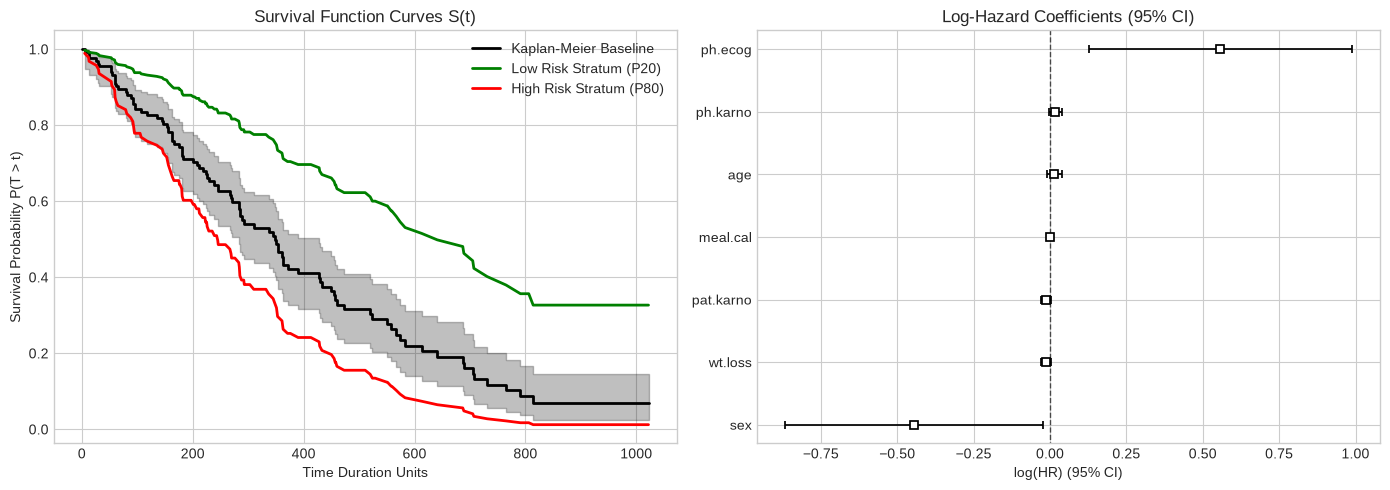

In [8]:
# STEP 8: SURVIVAL CURVES & HAZARD PROFILE VISUALIZATION
os.makedirs('plots', exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kaplan-Meier vs Stratified Cox Survival Curves
kmf.plot_survival_function(ax=axes[0], color='black', lw=2)

# Select high vs low risk individuals
q_low, q_high = np.percentile(test_risks, 20), np.percentile(test_risks, 80)
low_risk_sample = test_df[test_risks <= q_low].iloc[[0]]
high_risk_sample = test_df[test_risks >= q_high].iloc[[0]]

surv_low = model.predict_survival_function(low_risk_sample)
surv_high = model.predict_survival_function(high_risk_sample)

axes[0].plot(surv_low.index, surv_low.values, label='Low Risk Stratum (P20)', color='green', lw=2)
axes[0].plot(surv_high.index, surv_high.values, label='High Risk Stratum (P80)', color='red', lw=2)
axes[0].set_title("Survival Function Curves S(t)")
axes[0].set_xlabel("Time Duration Units")
axes[0].set_ylabel("Survival Probability P(T > t)")
axes[0].legend()

# Forest Plot of Hazard Ratios (exp(beta))
model.cph_.plot(ax=axes[1])
axes[1].set_title("Log-Hazard Coefficients (95% CI)")

plt.tight_layout()
plt.savefig('plots/survival_analysis.png', dpi=150)
plt.show()


In [9]:
# STEP 9: 5-FOLD CROSS VALIDATION CONCORDANCE
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_c_indices = []
for tr_idx, val_idx in kf.split(df):
    tr, val = df.iloc[tr_idx], df.iloc[val_idx]
    m = LifelinesCoxPHEstimator(duration_col='time', event_col='status', penalizer=0.05)
    m.fit(tr)
    v_risk = m.predict(val)
    c_idx = concordance_index(val['time'], -v_risk, val['status'])
    cv_c_indices.append(c_idx)

print(f"5-Fold CV Concordance Index: {np.mean(cv_c_indices):.4f} +/- {np.std(cv_c_indices):.4f}")


5-Fold CV Concordance Index: 0.6429 +/- 0.0468


In [10]:
# STEP 10 & 11: PRODUCTION SERIALIZATION
os.makedirs('production_models', exist_ok=True)
model_path = 'production_models/lung_cancer_coxph_pipeline.joblib'
joblib.dump(model, model_path, compress=3)
print(f"Pipeline saved to: {model_path} ({os.path.getsize(model_path)} bytes)")


Pipeline saved to: production_models/lung_cancer_coxph_pipeline.joblib (7368 bytes)


In [11]:
# STEP 12: REAL-TIME LATENCY SMOKE TEST
loaded = joblib.load(model_path)
sample = test_df.iloc[[0]]
for _ in range(10): _ = loaded.predict(sample)

lats = []
for _ in range(100):
    t0 = time.perf_counter()
    loaded.predict(sample)
    lats.append((time.perf_counter() - t0) * 1000)
avg_lat = np.mean(lats)
print(f"Mean Latency: {avg_lat:.4f} ms | P99: {np.percentile(lats, 99):.4f} ms")
assert avg_lat < 50.0, "Latency SLA violated"
print("✅ Production SLA Passed (< 50.0 ms)")


Mean Latency: 1.5922 ms | P99: 1.9359 ms
✅ Production SLA Passed (< 50.0 ms)


# STEP 13: EXECUTIVE DECISION MATRIX
| Analytical Paradigm | Binary Logistic Classification | Cox Proportional Hazards | Strategic Advantage |
| :--- | :--- | :--- | :--- |
| **Censoring Handling** | Truncates/discards right-censored data | **Unbiased partial likelihood conditioning** | **Zero survivorship bias** |
| **Time Horizon** | Static single window (e.g. 30 days) | **Continuous multi-horizon survival curve $S(t)$** | **Actionable customer decay trajectory** |
| **Scoring Metric** | AUC-ROC | **Harrell's Concordance Index (C-index)** | **Time-invariant ordinal risk ranking** |
